In [140]:
!pip install transformers -q

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
from transformers import AutoTokenizer

from data_loading.lca_dataset import LCADataset

import matplotlib.pyplot as plt


In [2]:
tokenizer = AutoTokenizer.from_pretrained('deepseek-ai/deepseek-coder-6.7b-base')


In [3]:
ds = LCADataset(lca_dir='/mnt/data/shared-data/lca/plcc_data_dir/', 
                language='python', 
                repo_snapshots_source='none')._completion_files


Generating train split: 857175 examples [00:30, 27969.59 examples/s]


In [4]:
ds

Dataset({
    features: ['repo', 'commit_hash', 'snapshot_hash', 'committer_date', 'year', 'datapoint_identifier', 'filename', 'content', 'total_lines', 'total_chars', 'lines', 'repo_num_chars_relevant', 'repo_num_chars_total', 'repo_num_chars_name'],
    num_rows: 857175
})

In [66]:
contents = ds['content']
tokens = list()
token_lens = list()
count = 0
batch_size = 10_000

while contents:
    new_tokens = tokenizer(contents[0:batch_size])['input_ids']
    tokens.extend(new_tokens)
    token_lens.extend([len(seq) for seq in new_tokens])
    contents = contents[batch_size:]
    count += 1
    print('|', end='')
    if count % 10 == 0:
        print(f'{count // 10 :02d}', end='')
    if count % 100 == 0:
        print()
        

||||||||||01||||||||||02||||||||||03||||||||||04||||||||||05||||||||||06||||||||||07||||||||||08||||||

In [70]:
sum([tl>6000 for tl in token_lens]) / len(token_lens), sum([tl<60 for tl in token_lens]) / len(token_lens)


(0.05203254877942077, 0.05165806282264415)

In [98]:
sum(token_lens) / 10 ** 9, sum([tl for tl in token_lens if 200< tl <8000]) / 10 ** 9, sum([tl for tl in token_lens if tl>8000]) / 10 ** 9

(1450238529, 1.004932954, 0.427823713)

In [132]:
max_range = 16_000 

total_tokens = [sum([tl for tl in token_lens if tl < thr]) / 10 ** 9 for thr in range(0, max_range, 100)]
total_datapoints = [len([tl for tl in token_lens if tl < thr]) for thr in range(0, max_range, 100)]

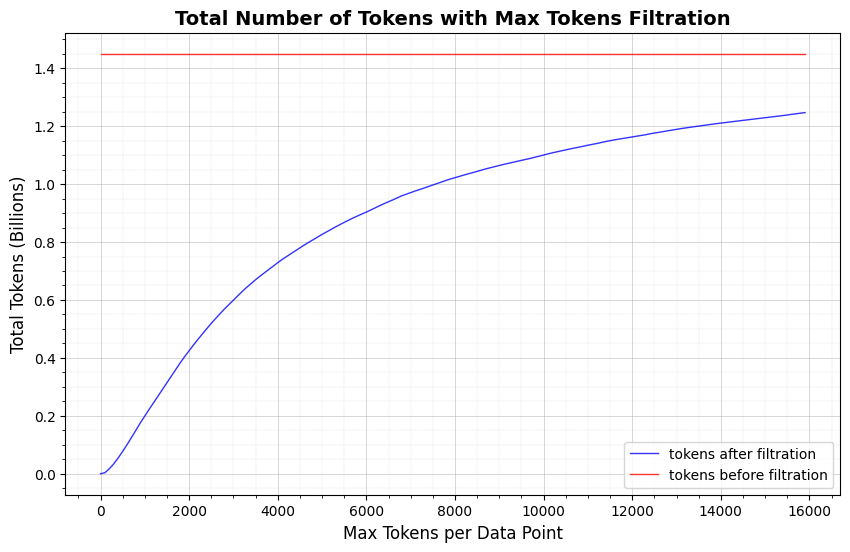

In [131]:
# Customize the figure size
plt.figure(figsize=(10, 6))

x_labels = list(range(0, max_range, 100))

# Plot data with line style and marker adjustments for clarity
plt.plot(
    x_labels,
    total_tokens,
    linestyle='-',
    linewidth=1,
    color='b',
    label='tokens after filtration',
    alpha=0.8
)

plt.plot(
    x_labels,
    [sum(token_lens) / 10**9] * len(x_labels),
    linestyle='-',
    linewidth=1,
    color='r',
    label='tokens before filtration',
    alpha=0.8
)

# Label the x and y axes
plt.xlabel('Max Tokens per Data Point', fontsize=12)
plt.ylabel('Total Tokens (Billions)', fontsize=12)

# Enable minor ticks to increase grid density
plt.minorticks_on()

# Add grid lines for both major and minor ticks
plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7)
plt.grid(which='minor', linestyle='--', linewidth=0.25, alpha=0.5)

# Add a title for context
plt.title('Total Number of Tokens with Max Tokens Filtration', fontsize=14, fontweight='bold')

# Display a legend for clarity
plt.legend()

# Show the plot
plt.show()

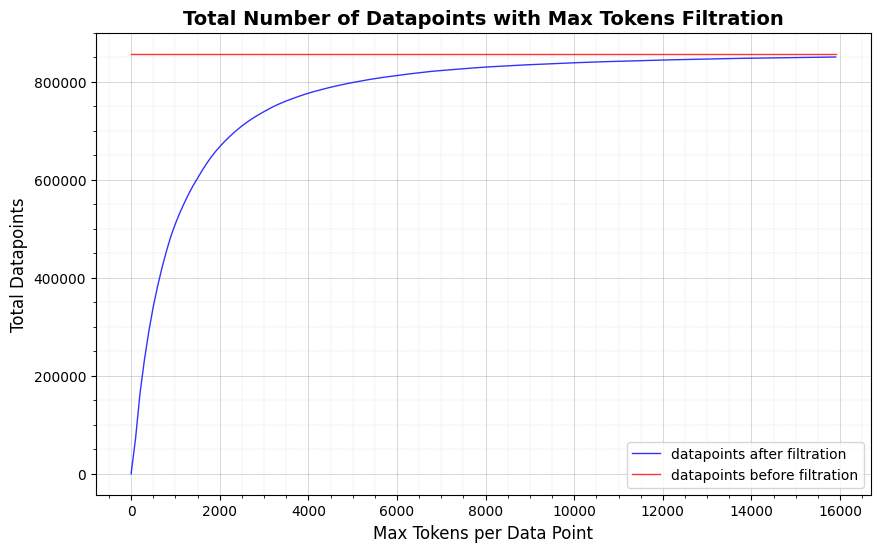

In [139]:
# Customize the figure size
plt.figure(figsize=(10, 6))

x_labels = list(range(0, max_range, 100))

# Plot data with line style and marker adjustments for clarity
plt.plot(
    x_labels,
    total_datapoints,
    linestyle='-',
    linewidth=1,
    color='b',
    label='datapoints after filtration',
    alpha=0.8
)

plt.plot(
    x_labels,
    [len(token_lens)] * len(x_labels),
    linestyle='-',
    linewidth=1,
    color='r',
    label='datapoints before filtration',
    alpha=0.8
)

# Label the x and y axes
plt.xlabel('Max Tokens per Data Point', fontsize=12)
plt.ylabel('Total Datapoints', fontsize=12)

# Enable minor ticks to increase grid density
plt.minorticks_on()

# Add grid lines for both major and minor ticks
plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7)
plt.grid(which='minor', linestyle='--', linewidth=0.25, alpha=0.5)

# Add a title for context
plt.title('Total Number of Datapoints with Max Tokens Filtration', fontsize=14, fontweight='bold')

# Display a legend for clarity
plt.legend()

# Show the plot
plt.show()